# Importing experimental data

**Dr. Panagiotis Sakagiannis, Dr. Alexandros Marantis**

## About this notebook

Larvaworld reads raw tracking output and converts it into one standardized dataset structure - the
same structure a simulation produces. That single fact is what makes the rest of the platform work
on recordings and simulations interchangeably : the same metrics, the same figures, the same
replay, the same model evaluation.

This notebook is about the machinery that does the conversion. It uses the two recording dishes
that ship with the package, so nothing has to be downloaded. Once you have followed it, the four
worked examples in this section apply it to real published datasets.

**What you will be able to do afterwards**

- Say what a **lab format** is and find the one that matches your tracker.
- Locate where raw and processed data live for each format.
- Import one recording, or many merged into a single dataset, with filters on track duration and
  animal count.
- Ask for the metrics and annotations you need at import time rather than recomputing later.
- Register a dataset under a reference ID and reload it in a later session.

**Prerequisites** : [Your first simulation](../1_getting_started/single_simulation.ipynb) is enough.

**Cost** : the inspection cells are instant. The import itself takes a minute or two and writes to
the package data folder, so it is behind a switch.

**Switches in this notebook**

| switch | default | what it turns on |
|---|---|---|
| `RUN_IMPORT_DEMO` | `False` | importing the shipped dishes, which writes to disc |
| `RUN_PLOTS` | `True` | figures from whatever dataset is available - cheap |

## Setup

Importing `larvaworld` initializes the configuration registry. `VERBOSE = 1` makes the import
report what it is doing, which is genuinely useful the first time you convert your own data.

In [1]:
%matplotlib inline

%load_ext param.ipython

import larvaworld
from larvaworld.lib import reg, util
from larvaworld.lib.reg.generators import LabFormat

larvaworld.VERBOSE = 1

# Tutorial safety switches
RUN_IMPORT_DEMO = False  # imports the shipped dishes and writes them to disc
RUN_PLOTS = True  # figures from an already available dataset (cheap)

MEDIA_DIR = "./media/import_datasets"
plot_dir = f"{MEDIA_DIR}/plots"

ds = []  # the datasets we end up with, filled in below

Welcome to the param IPython extension! (https://param.holoviz.org/)
Available magics: %params


Initializing larvaworld registry


Registry configured!


## Section 1 : Lab formats

Every tracker writes its own files : one file per animal or one file per quantity, different column
orders, different metadata, different units. Larvaworld does not try to guess. Instead each layout
is described once as a named **lab format**, and the import reads the raw files through it.

That is why importing a dataset needs so little : a folder and a format name.

In [2]:
lfIDs = reg.conf.LabFormat.confIDs
print("Available lab formats :", lfIDs)

Available lab formats : ['Arguello', 'Berni', 'DeepLabCut', 'Jovanic', 'Schleyer']


| lab format | suits data that looks like |
|---|---|
| `Jovanic` | one file per recorded quantity, all animals stacked together |
| `Schleyer` | one file per animal, plus per-dish metadata |
| `Berni`, `Arguello` | one file per animal, columns in a fixed order |
| `DeepLabCut` | DeepLabCut CSV/HDF5 exports, one file per video |

If one of them matches your tracker, everything in this section applies to your own data with only
the folder changed. If none does, a new format can be described and registered - it is a
configuration, not code.

### What a lab format holds

`LabFormat` has five parts, and each answers a different question about the raw data.

| field | what it describes |
|---|---|
| `labID` | the name of the format, and the folder it owns |
| `tracker` | the recording metadata : timestep, number of midline points, contour points, units |
| `filesystem` | how the files are laid out and named, and which columns to read |
| `env_params` | the arena the recordings were made in |
| `preprocess` | what has to be done to the raw values before anything else - rescaling, filtering, interpolation, transposition |

In [3]:
%params LabFormat

### Where the data lives

Each format owns a directory under the package data folder, with `raw` and `processed`
subdirectories. Import reads from the first and writes to the second. Both can be overridden
per import, which is what the public-dataset notebooks do when the download lands somewhere else.

In [4]:
labID = "Schleyer"
lf = reg.conf.LabFormat.get(labID)

print(f"All larvaworld data      : {larvaworld.DATA_DIR}")
print(f"{labID} lab folder       : {lf.path}")
print(f"  raw recordings go in   : {lf.raw_folder}")
print(f"  imported datasets      : {lf.processed_folder}")

All larvaworld data      : C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data
Schleyer lab folder       : C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SchleyerGroup
  raw recordings go in   : C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SchleyerGroup/raw
  imported datasets      : C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SchleyerGroup/processed


The tracker section is the one to read carefully before importing unfamiliar data : it declares the
frame rate, how many midline points were tracked, and whether a contour was recorded. Getting the
timestep wrong silently rescales every temporal metric downstream.

In [5]:
%params lf.tracker

## Section 2 : What an import call says

`import_dataset` takes a folder and turns it into a `LarvaDataset`. The arguments group into four
questions :

**Which files?**

| argument | meaning |
|---|---|
| `parent_dir` | the folder under `raw_folder` to read |
| `raw_folder` | an alternative location for the raw files |
| `merged` | treat every subfolder of `parent_dir` as part of one dataset |

**Which tracks to keep?**

| argument | meaning |
|---|---|
| `min_duration_in_sec` | discard tracks shorter than this - fragments say nothing about behavior |
| `max_Nagents` | cap the number of animals, useful to keep merged sets comparable |
| `time_slice` | keep only part of the recording |

**What to compute?**

| argument | meaning |
|---|---|
| `enrich_conf` | which metrics and annotations to derive during the import |

**What to call it, and whether to keep it?**

| argument | meaning |
|---|---|
| `id`, `group_id`, `color` | identity and appearance in later figures |
| `refID` | register it under this reference ID so it can be reloaded by name |
| `save_dataset` | write it to the processed folder |

The enrichment configuration deserves a note of its own : `proc_keys` selects the metric families
to compute (`angular`, `spatial`, ...), `anot_keys` the behavioral annotations (`bout_detection`
finds strides, turns and pauses; `interference` produces the per-stride metrics). Asking for them
at import time is cheaper than recomputing them later, and the figures further down depend on them.

In [6]:
constraints = util.AttrDict({"min_duration_in_sec": 90})

enr_kws = util.AttrDict(
    {
        "proc_keys": ["angular", "spatial"],
        "anot_keys": ["bout_detection", "bout_distribution", "interference"],
        "traj2origin": True,
        "tor_durs": [20],
        "dsp_starts": [0],
        "dsp_stops": [40, 60],
    }
)

print("Track filter :", constraints)
print()
print("Enrichment   :")
enr_kws.print()

Track filter : {'min_duration_in_sec': 90}

Enrichment   :
     proc_keys : ['angular', 'spatial']
     anot_keys : ['bout_detection', 'bout_distribution', 'interference']
     traj2origin : True
     tor_durs : [20]
     dsp_starts : [0]
     dsp_stops : [40, 60]


## Section 3 : A worked import

The package ships with two recording dishes in the Schleyer format, which is enough to show both
cases : a single dish, and several dishes merged into one dataset.

Note `merged=True` in the second call. Without it, `parent_dir` is one recording; with it, every
subfolder of `parent_dir` is read and the animals are pooled into a single dataset - which is how
you build a group of thirty control animals out of ten dishes.

This writes to the processed folder, so it is behind a switch.

In [7]:
if RUN_IMPORT_DEMO:
    # one dish
    d1 = lf.import_dataset(
        parent_dir="exploration/dish01",
        id="dish01",
        group_id="exploration",
        refID="exploration.dish01",
        enrich_conf=enr_kws,
        save_dataset=True,
        **constraints,
    )

    # every dish under 'exploration', pooled into one dataset
    d2 = lf.import_dataset(
        parent_dir="exploration",
        merged=True,
        max_Nagents=40,
        id="merged_dishes",
        group_id="exploration",
        refID="exploration.merged_dishes",
        enrich_conf=enr_kws,
        save_dataset=True,
        min_duration_in_sec=120,
    )

    ds = [d for d in (d1, d2) if d is not None]
    for d in ds:
        print(f"{d.id:16s} {d.config.N} larvae, dt={d.config.dt} s")
else:
    print("Set RUN_IMPORT_DEMO = True to import the shipped dishes.")

Set RUN_IMPORT_DEMO = True to import the shipped dishes.


## Section 4 : Reloading instead of re-importing

An import is done once. Everything afterwards works from the processed dataset, retrieved by its
reference ID - you never touch the raw files again.

This is also the cell that makes the rest of the notebook work without running the import : if the
datasets are already registered, it simply loads them.

In [8]:
print("Registered reference datasets :")
for refID in reg.conf.Ref.confIDs:
    print(f"  {refID}")

Registered reference datasets :
  Chris.larvae_single
  DeepLabCut.TopDown-2023-07-05
  DeepLabCut.TopDown-2024-02-17
  FeedingState.Fed
  FeedingState.Starved
  FeedingState.Sucrose
  FreeExploration.pooled
  FreeExploration.single_dish
  exploration.30controls
  exploration.dish01
  exploration.dish02


In [9]:
if not ds:
    wanted = [
        r
        for r in ["exploration.dish01", "exploration.dish02"]
        if r in reg.conf.Ref.confIDs
    ]
    for refID in wanted:
        try:
            ds.append(reg.loadRef(id=refID, load=True))
        except Exception as e:
            print(f"Could not load {refID!r} : {e}")

if ds:
    print("Loaded :", [d.id for d in ds])
else:
    print("No dataset available. Run Section 3, or import one of the public datasets.")

Loaded existing conf dish01


Loaded stored reference dataset : exploration.dish01
Loaded existing conf dish02
Loaded stored reference dataset : exploration.dish02
Loaded : ['dish01', 'dish02']


## Section 5 : What an imported dataset is

A `LarvaDataset` is three things, reachable as `d.data` or individually as `d.s`, `d.e` and `d.c` :

| part | what it is |
|---|---|
| **`s`** - step data | the timeseries : one row per (timestep, animal), one column per tracked or derived quantity |
| **`e`** - endpoint data | one row per animal, summarising its whole track |
| **`c`** - configuration | everything about the recording : arena, timestep, tracked points, group ID, colors |

This is exactly the structure a simulation produces, which is the whole point.

In [10]:
if ds:
    d = ds[0]
    s, e, c = d.data

    print(f"Dataset {d.id!r}")
    print(f"  step data     : {s.shape[0]} rows x {s.shape[1]} columns")
    print(f"  endpoint data : {e.shape[0]} rows x {e.shape[1]} columns")
    print(
        f"  arena         : {c.env_params.arena.dims} m, {c.env_params.arena.geometry}"
    )
    print(f"  timestep      : {c.dt} s, midline points : {c.Npoints}")

Dataset 'dish01'
  step data     : 40306 rows x 70 columns
  endpoint data : 14 rows x 8 columns
  arena         : (0.15, 0.15) m, circular
  timestep      : 0.0625 s, midline points : 12


In [11]:
if ds:
    display(ds[0].e.head())

,initial_t,final_t,num_ts,cum_dur,dt,final_tick,initial_tick,num_ticks
AgentID,,,,,,,,
Larva_0,0.0625,23.6250,1130,70.6250,0.020870,378,1,377
Larva_1,48.4375,24.6875,1160,71.6875,-0.020492,395,775,-380
Larva_10,65.0625,154.1875,2508,152.3750,0.035550,2467,1041,1426
Larva_11,154.7500,162.7500,2558,158.1250,0.003129,2604,2476,128
Larva_12,104.6250,129.3750,2035,119.3750,0.012168,2070,1674,396


## Section 6 : Figures

Larvaworld ships a library of plotting routines, each registered under a short name. You pick one
by name and hand it the datasets you want compared; group colors and labels are taken from the
datasets themselves, so a set of figures stays internally consistent.

In [12]:
print("Available plots :")
print(reg.graphs.ks)

Available plots :
['EEBvsQuality', 'PI (combo)', 'PI (simple)', 'PI heatmap', 'RvsS summary', 'angular pars', 'angular/epoch', 'auto_barplot', 'barplot', 'bearing to center/turn', 'bearing to source/epoch', 'bearing/turn', 'boxplot (grouped)', 'chemotaxis summary', 'correlated metrics', 'crawl pars', 'deb', 'dispersal', 'dispersal summary', 'distros', 'double patch', 'double-patch summary', 'endpoint box', 'endpoint hist', 'endpoint pars (scatter)', 'epochs', 'error barplot', 'error summary', 'error table', 'ethogram', 'eval summary', 'exploration summary', 'food intake (barplot)', 'food intake (timeplot)', 'foraging', 'freq powerspectrum', 'ga progress', 'gut', 'interference', 'kinematic analysis', 'lineplot', 'marked strides', 'model diff', 'model summary', 'model table', 'module hists', 'mpl', 'navigation index', 'nengo', 'odorscape', 'pathlength', 'sample track', 'sample tracks', 'sample_epochs', 'step box', 'step hist', 'stride Dbend', 'stride Dor', 'stride cycle', 'stride cycle m

One caveat before plotting, and it is the practical consequence of Section 2 : **a figure can only
be drawn from metrics that were actually computed**. The spatial plots below need the derived
trajectory columns, which come from the `spatial` entry of `proc_keys`. A dataset imported without
them will raise a `KeyError` rather than draw an empty figure.

So we check first, and fall back to the enriched reference dataset that ships with the package if
the datasets loaded above were imported without spatial processing.

In [13]:
REQUIRED = {"x", "y"}


def plottable(d):
    return REQUIRED.issubset(set(d.s.columns))


ds_plot = [d for d in ds if plottable(d)]

for d in ds:
    state = "has the spatial metrics" if plottable(d) else "imported without them"
    print(f"{d.id:16s} {state}")

if not ds_plot:
    print()
    print(f"Falling back to the enriched reference dataset {reg.default_refID!r}")
    try:
        ds_plot = [reg.loadRef(id=reg.default_refID, load=True)]
    except Exception as e:
        print(f"  not available : {e}")

plot_kws = {"datasets": ds_plot, "save_to": plot_dir, "show": False, "subfolder": None}

dish01           imported without them
dish02           imported without them

Loaded existing conf larvae_single
Loaded stored reference dataset : Chris.larvae_single
Loaded existing conf TopDown-2023-07-05


Loaded stored reference dataset : DeepLabCut.TopDown-2023-07-05
Loaded existing conf TopDown-2024-02-17
Loaded stored reference dataset : DeepLabCut.TopDown-2024-02-17
Loaded existing conf Fed
Loaded stored reference dataset : FeedingState.Fed
Loaded existing conf Starved
Loaded stored reference dataset : FeedingState.Starved
Loaded existing conf Sucrose
Loaded stored reference dataset : FeedingState.Sucrose
Loaded existing conf pooled
Loaded stored reference dataset : FreeExploration.pooled
Loaded existing conf single_dish
Loaded stored reference dataset : FreeExploration.single_dish
Loaded existing conf 30controls


Loaded stored reference dataset : exploration.30controls
Loaded existing conf dish01
Loaded stored reference dataset : exploration.dish01
Loaded existing conf dish02
Loaded stored reference dataset : exploration.dish02
Falling back to the enriched reference dataset 'exploration.30controls'


Loaded existing conf 30controls


Loaded stored reference dataset : exploration.30controls


The trajectories first - simply what the animals did.

Plot comparative_trajectories_default.pdf saved as ./media/import_datasets/plots\comparative_trajectories_default.pdf


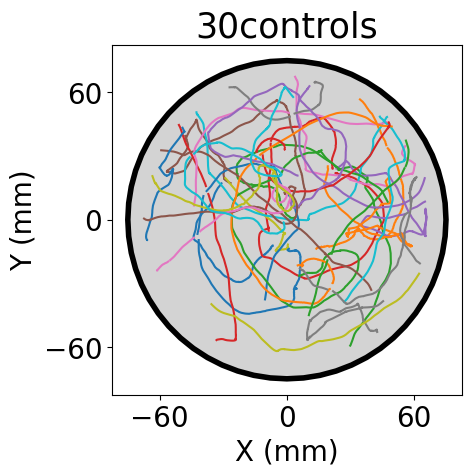

In [14]:
if RUN_PLOTS and ds_plot:
    display(reg.graphs.run("trajectories", **plot_kws))

The same paths, each translated so that it starts at the origin. This removes the arbitrary
starting position of each animal and makes the *shape and extent* of the paths comparable.

Plot comparative_trajectories_origin.pdf saved as ./media/import_datasets/plots\comparative_trajectories_origin.pdf


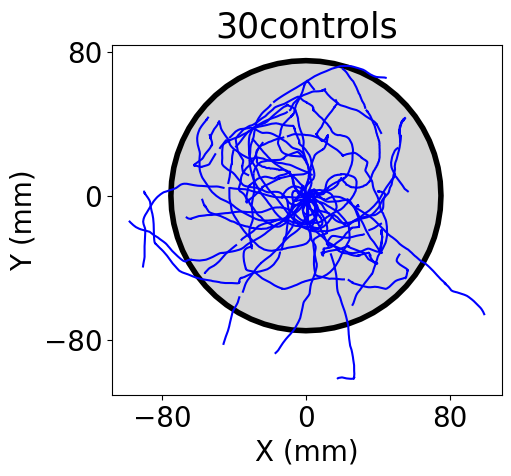

In [15]:
if RUN_PLOTS and ds_plot:
    display(
        reg.graphs.run("trajectories", mode="origin", single_color=True, **plot_kws)
    )

And a boxplot of endpoint metrics : one value per animal, summarising its whole track. Every plot
routine has a sensible default selection, but you can always name the metrics you want by their
short keys.

Plot end_box_basic.pdf saved as ./media/import_datasets/plots\end_box_basic.pdf


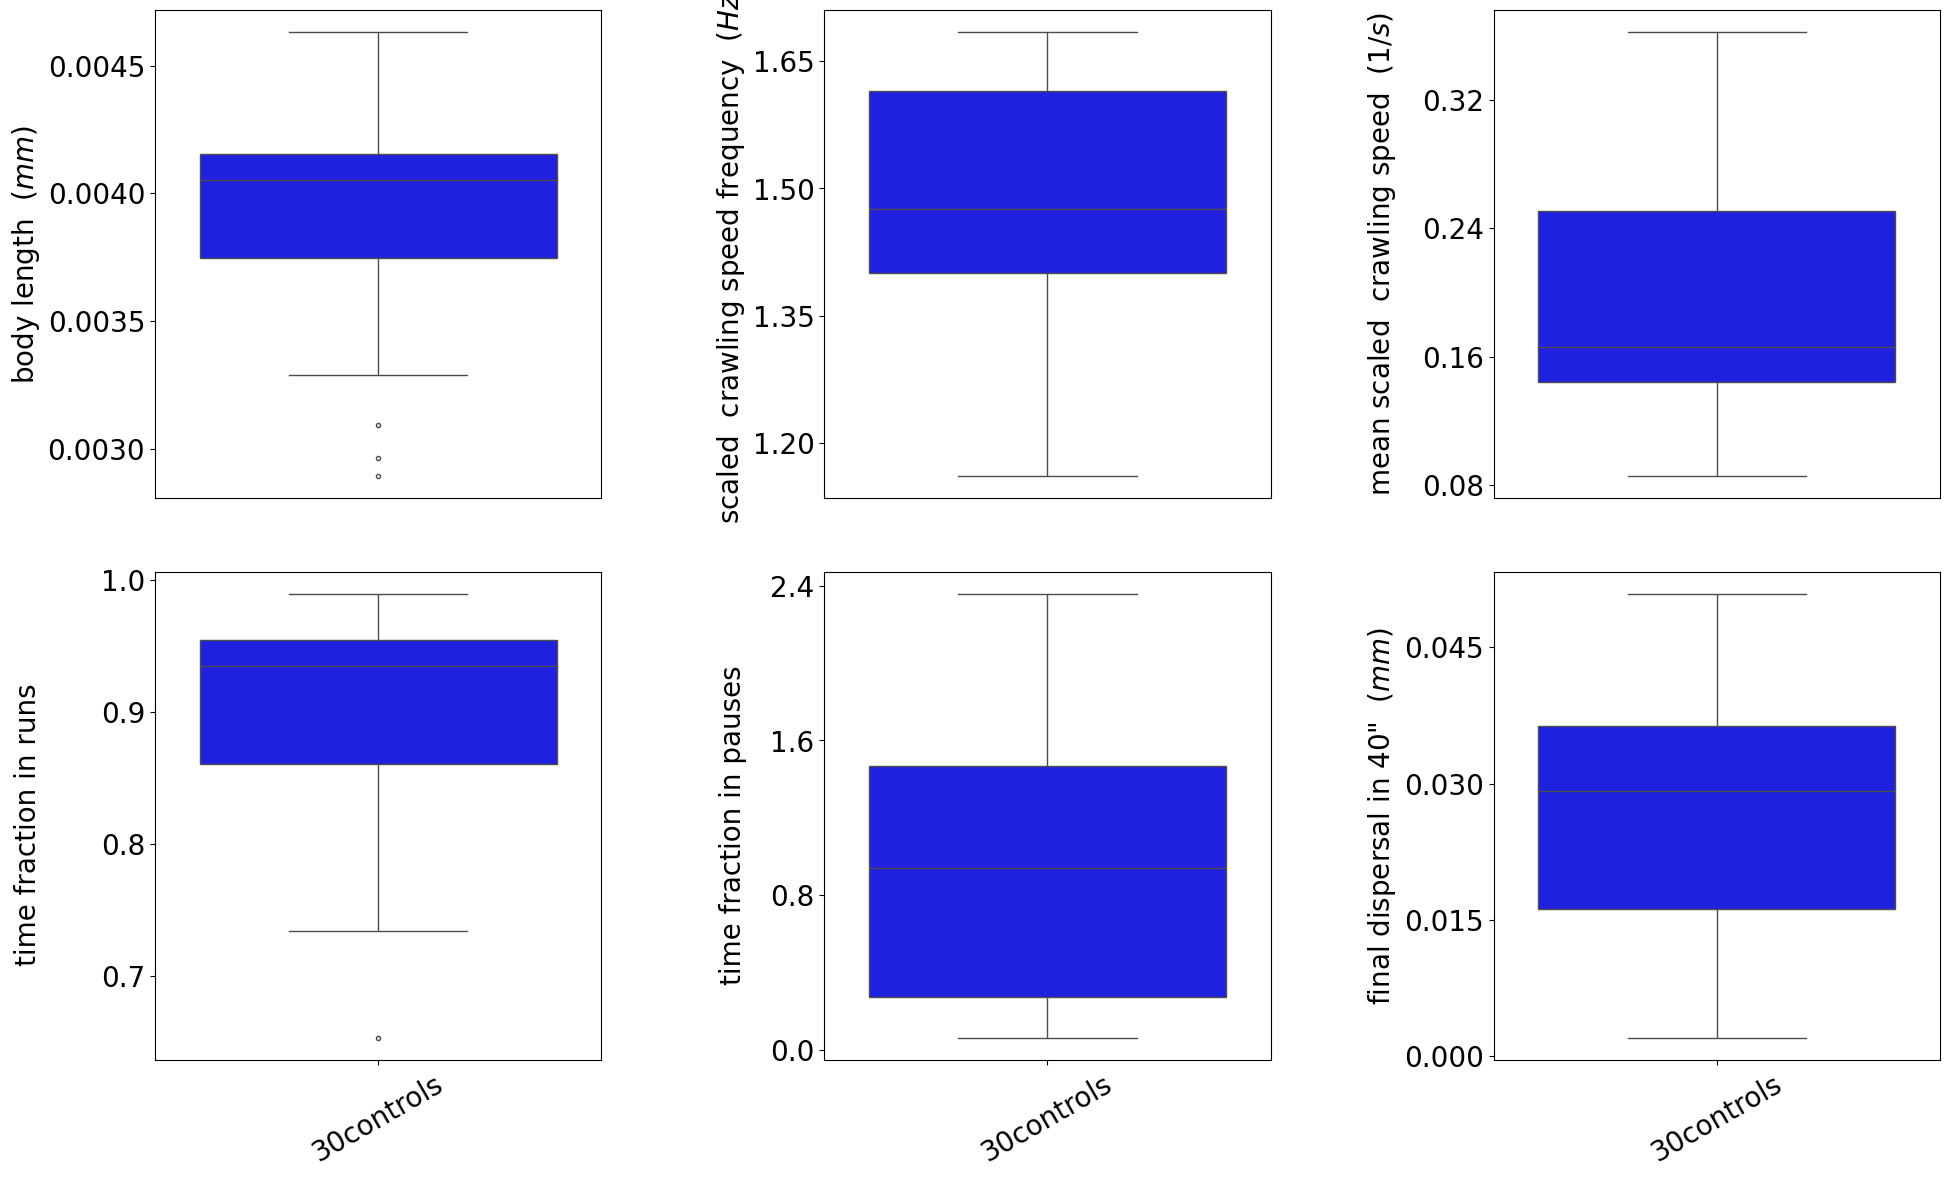

In [16]:
if RUN_PLOTS and ds_plot:
    display(
        reg.graphs.run(
            "endpoint box",
            ks=["l", "fsv", "sv_mu", "run_tr", "pau_tr", "dsp_0_40_fin"],
            **plot_kws,
        )
    )

## Where to go next

The four notebooks below apply everything above to real published datasets, each fetching its own
data :

- [Import a public dataset - template](import_public_dataset_template.ipynb) - the one to copy for
  your own recordings.
- [Free exploration of naive larvae](import_free_exploration_dataset.ipynb) - the baseline case.
- [DeepLabCut exports](import_DeepLabCut_dataset.ipynb) - pose estimation output rather than a
  purpose-built tracker.
- [Feeding-state locomotion](import_feeding_state_locomotion_dataset.ipynb) - three groups
  compared.

Then :

- [Replaying experiments](replay.ipynb) - watch what you just imported.
- [Model evaluation](../4_optimization_and_evaluation/model_evaluation.ipynb) - compare it against
  a model.
- Reference : [Lab formats and import](../../data_pipeline/lab_formats_import.md) and
  [Data processing](../../data_pipeline/data_processing.md).